In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

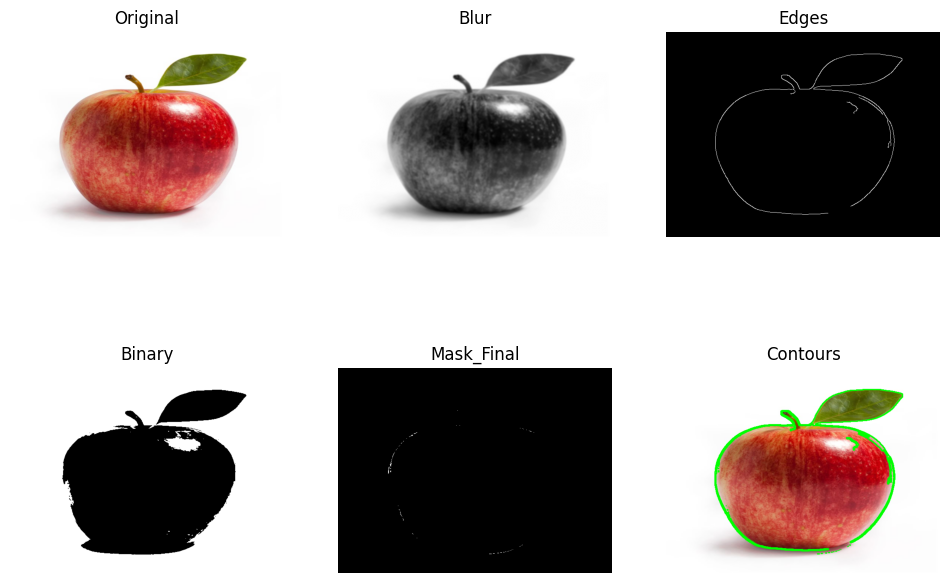

In [136]:
# 1. 이미지 읽기 (BGR)
img = cv2.imread("apple.jpg")
img = cv2.resize(img, (640, 480))

# 2. Grayscale 변환 - 계산량 감소
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3. Blur (노이즈 제거) - 작은 잡음 제거, 불필요한 edge 감소
blur = cv2.GaussianBlur(gray, (7, 7), 0)

# 4. Edge Detection (Canny) - threshold: 약한 edge와 강한 edge 구분
edges = cv2.Canny(blur, 50, 200)

# 5. Thresholding (Otsu) - Otsu Threshold : 이미지 histogram 분석으로 자동 임계값 선택
    # 전경(사과)와 배경(테이블) 밝기 차이를 극대화 → 윤곽 검출에 사용
_, binary = cv2.threshold(
    gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# 6. Morphology (Opening → 노이즈 제거)
    # Opening = Erosion(작은 흰색 점 제거) + Dilation(전경 영역 복원)
kernel = np.ones((3, 3), np.uint8)
opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
v = hsv[:, :, 2]

# 빨간색 H 범위 1 (0 ~ 10)
lower_red1 = np.array([0, 40, 50])  # S(50)와 V(50)의 최소값 설정
upper_red1 = np.array([10, 255, 255])
mask_hsv1 = cv2.inRange(hsv, lower_red1, upper_red1)

# 빨간색 H 범위 2 (170 ~ 179)
lower_red2 = np.array([170, 40, 50])
upper_red2 = np.array([179, 255, 255])
mask_hsv2 = cv2.inRange(hsv, lower_red2, upper_red2)

# 두 마스크 결합
mask_hsv = cv2.bitwise_or(mask_hsv1, mask_hsv2)

highlight_mask = cv2.inRange(v, 210, 255)  # 너무 밝은 영역 제거
mask_no_highlight = cv2.bitwise_and(opened, cv2.bitwise_not(highlight_mask))

mask_final = cv2.bitwise_and(mask_no_highlight, mask_hsv)

edges_dilated = cv2.dilate(edges, np.ones((3,3), np.uint8), iterations=1)
combined = cv2.bitwise_or(edges_dilated, mask_final)

# 7. Contour Detection (윤곽선 검출)
    # RETR_EXTERNAL → 외부 contour만
    # CHAIN_APPROX_SIMPLE → 꼭짓점만 저장, 메모리 절약
contours, _ = cv2.findContours(combined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 8. 윤곽선 그리기
result = img.copy()
cv2.drawContours(result, contours, -1, (0, 255, 0), 2)

# 결과 시각화
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# 출력
titles = ["Original", "Blur", "Edges", "Binary", "Mask_Final", "Contours"]
images = [
    cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
    blur,
    edges,
    binary,
    mask_final,
    result_rgb
]

plt.figure(figsize=(12,8))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap="gray" if i in [1,2,3,4] else None)
    plt.title(titles[i])
    plt.axis("off")
plt.show()

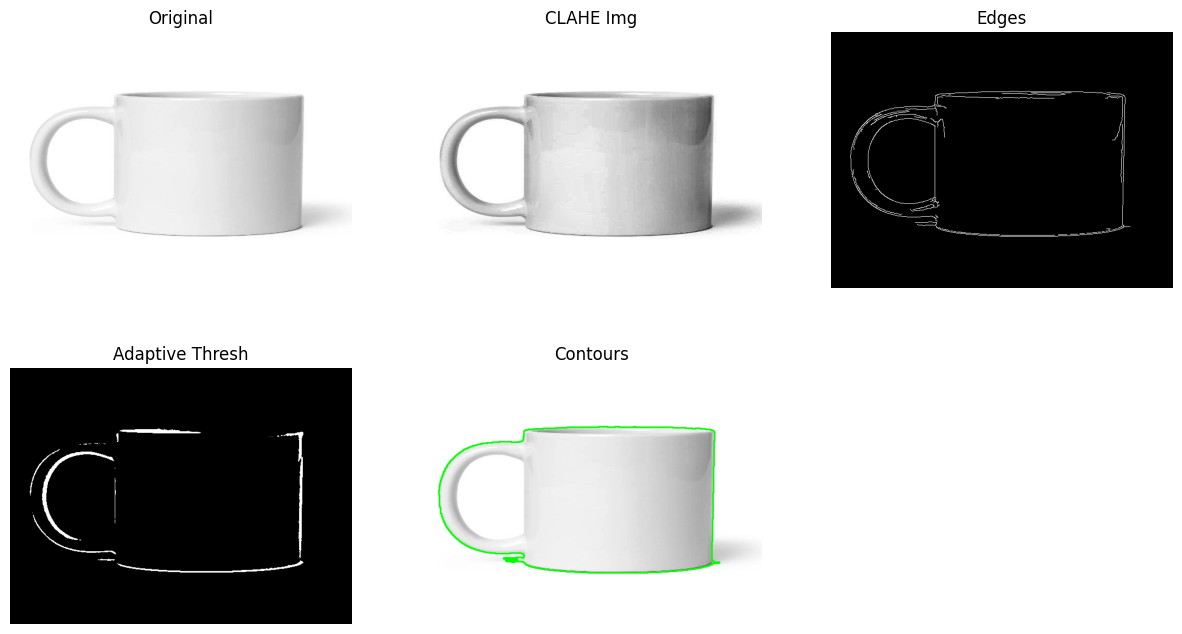

In [131]:
# 1. 이미지 읽기 (BGR)
img = cv2.imread("mug.jpg")
img = cv2.resize(img, (640, 480))
result = img.copy()

# 2. Grayscale & Blur
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# 3. CLAHE 적용: 
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)) # clipLimit, tileGridSize 조정 가능
clahe_img = clahe.apply(gray) # 그레이스케일 이미지에 적용

edges = cv2.Canny(clahe_img, 50, 150) 

# 5. Adaptive Thresholding 적용 (기존과 동일)
adaptive_thresh = cv2.adaptiveThreshold(
    blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY_INV, 27, 10
)

# 6. Morphology (Opening → 노이즈 제거)
kernel_open = np.ones((3, 3), np.uint8) 
opened_for_noise = cv2.morphologyEx(adaptive_thresh, cv2.MORPH_OPEN, kernel_open) 
edges_dilated = cv2.dilate(edges, np.ones((3,3), np.uint8), iterations=1)
combined = cv2.bitwise_or(edges_dilated, opened_for_noise) 

# 8. Contour Detection
contours, _ = cv2.findContours(
    combined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

# 9. 윤곽선 그리기
result = img.copy()
cv2.drawContours(result, contours, -1, (0, 255, 0), 2)

# 결과 시각화
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

titles = ["Original", "CLAHE Img", "Edges", "Adaptive Thresh", "Contours"] 
images = [
    cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
    clahe_img, 
    edges,
    adaptive_thresh,
    result_rgb
]

plt.figure(figsize=(15,8))
for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap="gray" if i in [1,2,3] else None)
    plt.title(titles[i])
    plt.axis("off")
plt.show()